In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import json

import html
import re
import unicodedata
from sklearn.model_selection import train_test_split

In [4]:
train_df = pd.read_csv('/content/Train.csv')
test_df = pd.read_csv('/content/Test.csv')

## Task 1. Problem & data investigation

In [5]:
train_df.head(10)

,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence
5,ID_0052TYKI,"Yes men rape women. But women also rape men, y...",sexual_violence
6,ID_0058QG76,"My Husband Beats Me Frequently, Wife Tells Cou...",Physical_violence
7,ID_005VM1DJ,Pretty sure he raped a 16yr old girl with 2 fr...,sexual_violence
8,ID_0060BW8R,TW sorry to hear that and yeah he recently th...,sexual_violence
9,ID_007FAIEI,"""I understand that... My father was abusive as...",sexual_violence


In [ ]:
train_df.describe()

,Tweet_ID,tweet,type
count,39650,39650,39650
unique,39650,39642,5
top,ID_ZZZ8QEKT,my run up today: - havent eaten in 30 hours -...,sexual_violence
freq,1,3,32648


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39650 entries, 0 to 39649
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  39650 non-null  object
 1   tweet     39650 non-null  object
 2   type      39650 non-null  object
dtypes: object(3)
memory usage: 929.4+ KB


In [ ]:
train_df['type'].unique()

array(['sexual_violence', 'Physical_violence', 'emotional_violence',
       'Harmful_Traditional_practice', 'economic_violence'], dtype=object)

In [ ]:
train_df['type'].value_counts()

,count
type,
sexual_violence,32648
Physical_violence,5946
emotional_violence,651
economic_violence,217
Harmful_Traditional_practice,188


In [6]:
# Returns the total number of duplicate rows
train_df[train_df['tweet'].duplicated()]


,Tweet_ID,tweet,type
11374,ID_ABHE48A4,my run up today: - havent eaten in 30 hours -...,emotional_violence
26107,ID_NTI32D5F,"My homie invited me over to smoke, then he sta...",sexual_violence
28050,ID_PKQ5LRN1,I was insulted and humiliated in public by one...,emotional_violence
30236,ID_RIVSXQSR,my run up today: - havent eaten in 30 hours -...,emotional_violence
30504,ID_RS9ZNVRX,account is temporarily unavailable because it ...,Physical_violence
30726,ID_RZRGED0E,"and he forced me hug to him, and later he piss...",sexual_violence
37104,ID_XSCUCJBD,"This is my story. July 24, 2017 I was raped. ...",sexual_violence
37666,ID_YAV6NN9N,"I was referring to stuff like rape, DV, prosti...",Harmful_Traditional_practice


In [7]:
# Drop duplicates based only on the 'tweet' column
train_df = train_df.drop_duplicates(subset=['tweet'])

# Verify that there are no duplicate tweets left
print("Remaining duplicate tweets:", train_df['tweet'].duplicated().sum())


Remaining duplicate tweets: 0


In [ ]:
def plot_distribution(df, metric_col, title_prefix):
    categories = ['Overall'] + list(df['type'].unique())
    fig, axes = plt.subplots(len(categories), 1, figsize=(10, 3 * len(categories)), sharex=True)

    for i, cat in enumerate(categories):
        ax = axes[i]
        if cat == 'Overall':
            data = df[metric_col]
        else:
            data = df[df['type'] == cat][metric_col]

        # Calculate statistics
        median_val = data.median()
        p95_val = data.quantile(0.95)

        # Plot distribution
        sns.histplot(data, bins=50, ax=ax, kde=True, color='skyblue')
        ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
        ax.axvline(p95_val, color='orange', linestyle='--', linewidth=1.5, label=f'95th Pct: {p95_val:.1f}')

        ax.set_title(f"{title_prefix} - {cat} (n={len(data)})")
        ax.set_ylabel('Density/Count')
        ax.legend()

    plt.xlabel(title_prefix)
    plt.savefig(f"{title_prefix}.png")
    plt.tight_layout()
    plt.show()

--- Word Count Distributions ---


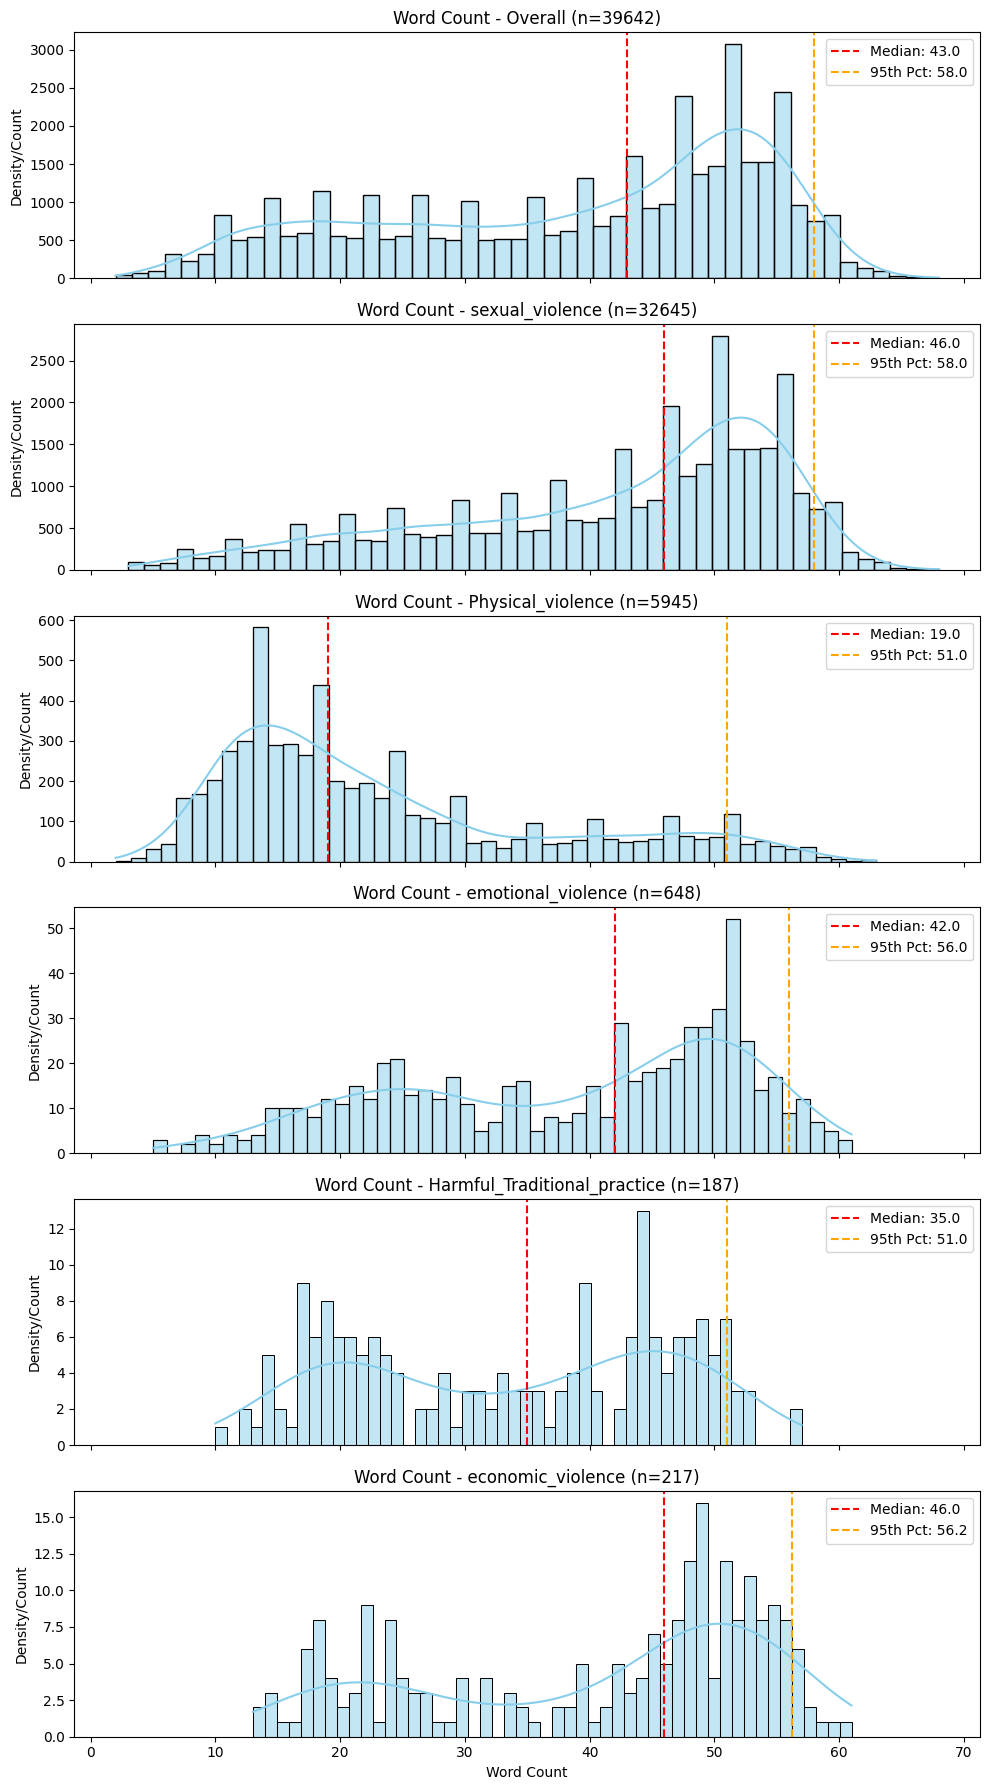

In [ ]:
# Calculate word counts
train_df['word_count'] = train_df['tweet'].apply(lambda x: len(str(x).split()))

# Plot distribution
print("--- Word Count Distributions ---")
plot_distribution(train_df, 'word_count', 'Word Count')


--- Character Count Distributions ---


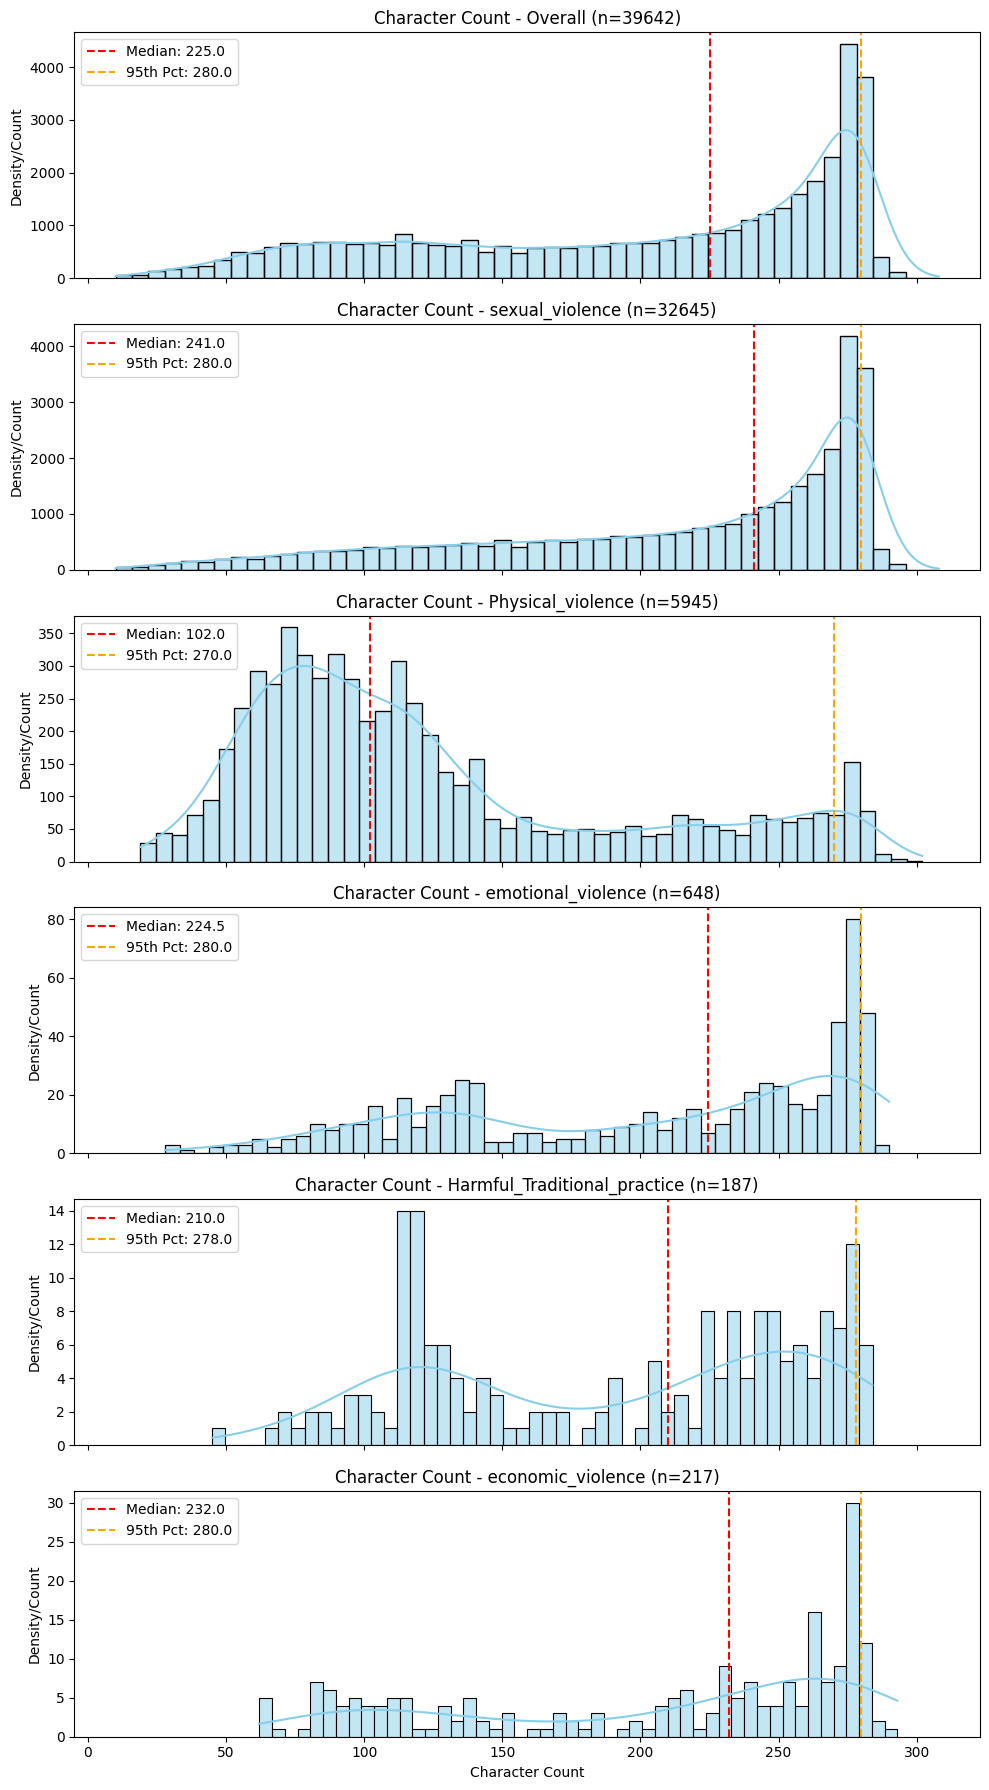

In [ ]:
# Calculate character counts
train_df['char_count'] = train_df['tweet'].apply(lambda x: len(str(x)))

# Plot distribution
print("\n--- Character Count Distributions ---")
plot_distribution(train_df, 'char_count', 'Character Count')


## Task 2. Related work and sequential model selection

This project classifies tweets about gender-based violence (GBV) into five categories: sexual violence, physical violence, emotional violence, economic violence, and harmful traditional practices. The training data is highly imbalanced: sexual violence accounts for about 82% of examples, while the two smallest classes each account for less than 1%. Our main research question is: **Do models that learn from token sequences classify these five categories more effectively than a lexical baseline, especially for rare classes?** The [Zindi challenge](https://zindi.world/competitions/gender-based-violence-tweet-classification-challenge-2025/data) defines the dataset and task.

Research on related forms of online gendered harm shows that fine-grained labels are useful but difficult to classify consistently. [Kirk et al. (2023)](https://aclanthology.org/2023.semeval-1.305/) study categories of online sexism and analyse classification errors. [Zeinert et al. (2021)](https://aclanthology.org/2021.acl-long.247/) discuss the complexity of annotating online misogyny, while [Arora et al. (2024)](https://aclanthology.org/2024.woah-1.16/) show the importance of language and context in gendered-abuse tweets. These are related tasks, **not evaluations on our dataset**. They motivate careful interpretation of labels, per-class evaluation, and error analysis.

We selected **five substantially different approaches**:

| Approach | Why we chose it |
| :--- | :--- |
| **TF–IDF + linear SVM** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">A non-sequential baseline that tests how far word and character patterns can take us. TF–IDF with SVM has been used for offensive-language classification in tweets ([Saroj et al., 2020](https://aclanthology.org/2020.semeval-1.265/)).</div> |
| **Simple RNN** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Processes words in order and carries information forward through a hidden state. It establishes whether basic sequence learning improves on the lexical baseline ([Elman, 1990](https://doi.org/10.1207/s15516709cog1402_1)).</div> |
| **GRU** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Adds gates to recurrent processing. We will test whether it retains useful context more effectively than the Simple RNN ([Cho et al., 2014](https://aclanthology.org/D14-1179/)).</div> |
| **LSTM** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Uses a memory cell designed to help learn longer dependencies. We will test whether this helps distinguish categories when meaning depends on surrounding words ([Hochreiter & Schmidhuber, 1997](https://doi.org/10.1162/neco.1997.9.8.1735)).</div> |
| **BERTweet Transformer** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Uses contextual representations from a model pretrained on English tweets. It may handle informal tweet language better, but this must be tested on our data ([Nguyen et al., 2020](https://aclanthology.org/2020.emnlp-demos.2/)). Its Transformer architecture builds on attention-based sequence modelling ([Vaswani et al., 2017](https://proceedings.neurips.cc/paper/2017/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html)).</div> |

The three recurrent models compare different ways of learning from word order and retaining context. BERTweet adds a pretrained, attention-based approach. The SVM tells us whether the added complexity improves on a simpler method. Because BERTweet also differs in **pretraining, tokenizer, and model size**, any performance difference cannot be attributed to its architecture alone.

We will evaluate every approach on the **same held-out data**, using **macro F1 as the primary metric**, plus per-class precision, recall, F1, a confusion matrix, and accuracy. This is important because a model could achieve high accuracy by favoring the dominant sexual-violence class while missing rare categories. We will also inspect ambiguous and incorrectly classified tweets. Results from the papers above motivate these choices; **our own experiments will determine which approach works best on this dataset**.

## Task 3. Iterative model training

Let's first create a function that does the following:audit, light text cleaning, conflict checks, label encoding, and a stratified split. The function stops before BERTweet tokenization.

In [15]:
def prepare_gbv_data(train_df, test_df, val_size=0.20, seed=42):
    """
    Clean, audit, and split GBV tweet data.

    Everything is returned as in-memory variables; no files are saved.

    Returns
    -------
    train_set, val_set  : DataFrames
        Columns: Tweet_ID, tweet, label_id
    test_set : DataFrame
        Columns: Tweet_ID, tweet
    label_to_id : dict
        Mapping from original class name to integer ID
    audit : dict
        Data-quality checks and class distributions
    """
    train_required = {"Tweet_ID", "tweet", "type"}
    test_required = {"Tweet_ID", "tweet"}

    if train_required - set(train_df.columns):
        raise ValueError(f"Missing training columns: {train_required - set(train_df.columns)}")
    if test_required - set(test_df.columns):
        raise ValueError(f"Missing test columns: {test_required - set(test_df.columns)}")

    def clean_text(value):
        if pd.isna(value):
            return ""

        text = html.unescape(str(value))
        text = unicodedata.normalize("NFC", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    train = train_df.copy()
    test = test_df.copy()
    audit = {}

    # Audit the original inputs.
    audit["input_rows"] = len(train)
    audit["missing_tweets"] = int(train["tweet"].isna().sum())
    audit["missing_labels"] = int(train["type"].isna().sum())
    audit["duplicate_ids"] = int(train["Tweet_ID"].duplicated().sum())
    audit["exact_duplicate_tweets"] = int(train["tweet"].dropna().duplicated().sum())

    if audit["duplicate_ids"]:
        raise ValueError(
            "Duplicate Tweet_ID values found in training data. "
            "Inspect these before continuing."
        )

    # Clean text without removing punctuation, changing case, or
    # deleting words. BERTweet tokenization will happen later.
    train["tweet"] = train["tweet"].map(clean_text)
    test["tweet"] = test["tweet"].map(clean_text)

    audit["blank_after_cleaning"] = int(train["tweet"].eq("").sum())

    # Remove unusable labeled rows.
    train = train.loc[train["tweet"].ne("") & train["type"].notna()].copy()

    # Detect texts that have more than one label BEFORE deduplication.
    labels_per_text = train.groupby("tweet")["type"].nunique()
    conflicting_texts = labels_per_text[
        labels_per_text > 1
    ].index

    audit["conflicting_texts"] = len(conflicting_texts)
    audit["rows_with_conflicting_labels"] = int(train["tweet"].isin(conflicting_texts).sum())

    # Exclude all copies of a text with conflicting labels.
    train = train.loc[
        ~train["tweet"].isin(conflicting_texts)
    ].copy()

    # Keep one copy of each remaining cleaned text.
    audit["duplicates_after_cleaning"] = int(train.duplicated(subset="tweet").sum())
    train = train.drop_duplicates(subset="tweet", keep="first").reset_index(drop=True)

    audit["usable_labeled_rows"] = len(train)
    audit["class_counts"] = train["type"].value_counts().to_dict()
    audit["class_percentages"] = (
        train["type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    # Create a stable mapping and encode the training labels.
    class_names = sorted(train["type"].unique())
    label_to_id = {
        class_name: label_id
        for label_id, class_name in enumerate(class_names)
    }
    train["label_id"] = train["type"].map(label_to_id).astype(int)

    # Keep only the three columns you need before splitting.
    train = train[["Tweet_ID", "tweet", "label_id"]]

    train_set, val_set = train_test_split(
        train,
        test_size=val_size,
        random_state=seed,
        stratify=train["label_id"],
    )
    train_set = train_set.reset_index(drop=True)
    val_set = val_set.reset_index(drop=True)

    audit["training_rows"] = len(train_set)
    audit["validation_rows"] = len(val_set)
    audit["training_class_counts"] = (train_set["label_id"].value_counts().sort_index().to_dict())
    audit["validation_class_counts"] = (val_set["label_id"].value_counts().sort_index().to_dict())

    # Preserve every test ID: predictions will need to match these IDs.
    audit["test_rows"] = len(test)
    audit["blank_test_tweets"] = int(test["tweet"].eq("").sum())
    audit["duplicate_test_ids"] = int(test["Tweet_ID"].duplicated().sum())

    if audit["duplicate_test_ids"]:
        raise ValueError("Duplicate Tweet_ID values found in test data.")
    if audit["blank_test_tweets"]:
        raise ValueError("Blank test tweets found. Inspect them before generating predictions.")

    test_set = test[["Tweet_ID", "tweet"]].reset_index(drop=True)

    return train_set, val_set, test_set, label_to_id, audit

In [16]:
train_set, val_set, test_set, label_to_id, audit = prepare_gbv_data(
    train_df,
    test_df,
    val_size=0.20,
    seed=42,
)

print("Shapes:")
print("Train:", train_set.shape)
print("Validation:", val_set.shape)
print("Test:", test_set.shape)

print("\nColumns:")
print("Train:", train_set.columns.tolist())
print("Validation:", val_set.columns.tolist())
print("Test:", test_set.columns.tolist())

print("\nLabel mapping:", label_to_id)

print("\nAudit:")
for name, value in audit.items():
    print(f"{name}: {value}")

display(train_set.head())

Shapes:
Train: (31354, 3)
Validation: (7839, 3)
Test: (15581, 2)

Columns:
Train: ['Tweet_ID', 'tweet', 'label_id']
Validation: ['Tweet_ID', 'tweet', 'label_id']
Test: ['Tweet_ID', 'tweet']

Label mapping: {'Harmful_Traditional_practice': 0, 'Physical_violence': 1, 'economic_violence': 2, 'emotional_violence': 3, 'sexual_violence': 4}

Audit:
input_rows: 39642
missing_tweets: 0
missing_labels: 0
duplicate_ids: 0
exact_duplicate_tweets: 0
blank_after_cleaning: 0
conflicting_texts: 0
rows_with_conflicting_labels: 0
duplicates_after_cleaning: 449
usable_labeled_rows: 39193
class_counts: {'sexual_violence': 32587, 'Physical_violence': 5556, 'emotional_violence': 648, 'economic_violence': 215, 'Harmful_Traditional_practice': 187}
class_percentages: {'sexual_violence': 83.14, 'Physical_violence': 14.18, 'emotional_violence': 1.65, 'economic_violence': 0.55, 'Harmful_Traditional_practice': 0.48}
training_rows: 31354
validation_rows: 7839
training_class_counts: {0: 150, 1: 4445, 2: 172, 3: 518

,Tweet_ID,tweet,label_id
0,ID_JZKGMEN5,Does anyone know the latest on Kadian Nelson -...,4
1,ID_TLXD2FVQ,"when i was 14 i was raped, and it sucks, becau...",4
2,ID_EHL3NN62,": *recommends a novel to me, saying it’s refre...",4
3,ID_WPXEOR0U,The fucking guilt trip he tried to pull “oh wh...,4
4,ID_EIQFN21E,My husband and his family went in together to ...,1


### Cleaning and class distribution

After removing eight exact duplicate tweets, the dataset contained **39,642 rows**. Light cleaning standardized whitespace, including leading and trailing spaces, repeated spaces, tabs, and nonbreaking spaces. This revealed **449 additional duplicate rows**: their cleaned text matched another tweet even though their original text was not identical. We kept one copy of each cleaned tweet, leaving **39,193 labeled rows**. This step did not remove words or punctuation.

| Class | Before cleaning | Before (%) | After cleaning | After (%) |
|---|---:|---:|---:|---:|
| Sexual violence | 32,645 | 82.35% | 32,587 | 83.14% |
| Physical violence | 5,945 | 15.00% | 5,556 | 14.18% |
| Emotional violence | 648 | 1.63% | 648 | 1.65% |
| Economic violence | 217 | 0.55% | 215 | 0.55% |
| Harmful traditional practices | 187 | 0.47% | 187 | 0.48% |

Most of the newly identified duplicates were in the **physical violence** class (389 of 449), which explains why its share fell from **15.00% to 14.18%**. The dataset remains strongly imbalanced: sexual violence represents **83.14%** of the cleaned data, while each of the two smallest classes represents less than **0.6%**. We will therefore examine per-class results and macro F1, rather than relying on accuracy alone.